In [1]:
import pandas as pd


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
df = pd.read_csv("/content/drive/MyDrive/CRIS/wireless_headphones_reviews_cleaned_full.csv")

df.head()

,rating,title,text,images,asin,parent_asin,user_id,timestamp,helpful_vote,verified_purchase,review_full,review_time,review_date,review_year,review_month,review_clean,review_length,sentiment_label,importance_score
0,5.0,Great purchase!,Excellent product. Great customer service.,[],B01M74RA05,B01M74RA05,AHQQ62COZ3ANN33IRXZ6Z4KF664A,1486512426000,0,True,Great purchase! Excellent product. Great custo...,2017-02-08 00:07:06.000,2017-02-08,2017,2017-02,great purchase excellent product great custome...,7,positive,0.07
1,3.0,Battery life sucks,Battery lasted 2 months ...sucks,[],B085L34V8J,B085L34V8J,AESGKFNIDELMTPT7OLS67JA545JA,1603999669246,0,True,Battery life sucks Battery lasted 2 months ......,2020-10-29 19:27:49.246,2020-10-29,2020,2020-10,battery life sucks battery lasted 2 months sucks,8,neutral,6.08
2,1.0,JUNK!!!,These are absolute junk. Not at all the Bose ...,[],B01L7PWBRG,B0B62FJF1J,AEAU4B3HGL46SP3ARQZZ3B7PDA4Q,1489026041000,0,False,JUNK!!! These are absolute junk. Not at all t...,2017-03-09 02:20:41.000,2017-03-09,2017,2017-03,junk these are absolute junk not at all the bo...,18,negative,12.18
3,2.0,Poor connection,"Crappy sound quality, poor fit, volume control...",[],B07CX38CQ2,B07GC8NMB8,AE427MY65PZ6FNZ2IY6HCTIIQZEQ,1565129082806,0,True,"Poor connection Crappy sound quality, poor fit...",2019-08-06 22:04:42.806,2019-08-06,2019,2019-08,poor connection crappy sound quality poor fit ...,15,negative,9.15
4,4.0,These earbuds work great. It has very good sou...,These earbuds work great. It has very good so...,[],B00H36UL5I,B00H36UL5I,AHATA6X6MYTC3VNBFJ3WIYVK257A,1515081112399,0,False,These earbuds work great. It has very good sou...,2018-01-04 15:51:52.399,2018-01-04,2018,2018-01,these earbuds work great it has very good soun...,41,positive,3.41


In [4]:
aspect_keywords = {
    "battery": ["battery", "charge", "charging", "drain", "power"],
    "sound": ["sound", "audio", "bass", "treble", "volume", "noise"],
    "comfort": ["comfort", "fit", "ear", "wear", "tight", "loose"],
    "connectivity": ["connect", "bluetooth", "pair", "disconnect"],
    "anc": ["noise cancelling", "anc", "noise cancel"],
    "microphone": ["mic", "microphone", "call", "voice"],
    "build": ["build", "quality", "durable", "broke", "plastic"],
    "price": ["price", "cost", "expensive", "cheap", "value"]
}

In [5]:
def extract_aspects(text):
    aspects_found = []

    for aspect, keywords in aspect_keywords.items():
        if any(keyword in text for keyword in keywords):
            aspects_found.append(aspect)

    return aspects_found

In [6]:
df["aspects"] = df["review_clean"].apply(extract_aspects)
df[["review_clean", "aspects"]].head()

,review_clean,aspects
0,great purchase excellent product great custome...,[]
1,battery life sucks battery lasted 2 months sucks,[battery]
2,junk these are absolute junk not at all the bo...,[build]
3,poor connection crappy sound quality poor fit ...,"[sound, comfort, connectivity, build]"
4,these earbuds work great it has very good soun...,"[sound, comfort, connectivity, build]"


In [7]:
df_exploded = df.explode("aspects")
df_exploded.head()

,rating,title,text,images,asin,parent_asin,user_id,timestamp,helpful_vote,verified_purchase,review_full,review_time,review_date,review_year,review_month,review_clean,review_length,sentiment_label,importance_score,aspects
0,5.0,Great purchase!,Excellent product. Great customer service.,[],B01M74RA05,B01M74RA05,AHQQ62COZ3ANN33IRXZ6Z4KF664A,1486512426000,0,True,Great purchase! Excellent product. Great custo...,2017-02-08 00:07:06.000,2017-02-08,2017,2017-02,great purchase excellent product great custome...,7,positive,0.07,NaN
1,3.0,Battery life sucks,Battery lasted 2 months ...sucks,[],B085L34V8J,B085L34V8J,AESGKFNIDELMTPT7OLS67JA545JA,1603999669246,0,True,Battery life sucks Battery lasted 2 months ......,2020-10-29 19:27:49.246,2020-10-29,2020,2020-10,battery life sucks battery lasted 2 months sucks,8,neutral,6.08,battery
2,1.0,JUNK!!!,These are absolute junk. Not at all the Bose ...,[],B01L7PWBRG,B0B62FJF1J,AEAU4B3HGL46SP3ARQZZ3B7PDA4Q,1489026041000,0,False,JUNK!!! These are absolute junk. Not at all t...,2017-03-09 02:20:41.000,2017-03-09,2017,2017-03,junk these are absolute junk not at all the bo...,18,negative,12.18,build
3,2.0,Poor connection,"Crappy sound quality, poor fit, volume control...",[],B07CX38CQ2,B07GC8NMB8,AE427MY65PZ6FNZ2IY6HCTIIQZEQ,1565129082806,0,True,"Poor connection Crappy sound quality, poor fit...",2019-08-06 22:04:42.806,2019-08-06,2019,2019-08,poor connection crappy sound quality poor fit ...,15,negative,9.15,sound
3,2.0,Poor connection,"Crappy sound quality, poor fit, volume control...",[],B07CX38CQ2,B07GC8NMB8,AE427MY65PZ6FNZ2IY6HCTIIQZEQ,1565129082806,0,True,"Poor connection Crappy sound quality, poor fit...",2019-08-06 22:04:42.806,2019-08-06,2019,2019-08,poor connection crappy sound quality poor fit ...,15,negative,9.15,comfort


In [8]:
df_exploded["aspects"].value_counts()

,count
aspects,
comfort,2839
sound,2629
connectivity,1587
build,1441
battery,1352
price,1230
microphone,771
anc,675


In [9]:
aspect_sentiment = df_exploded.groupby("aspects")["rating"].mean().sort_values()
aspect_sentiment

,rating
aspects,
microphone,3.819715
connectivity,3.848771
build,3.875087
battery,3.901627
comfort,3.926383
sound,3.988208
price,4.040650
anc,4.060741


In [10]:
df_exploded[df_exploded["rating"] <= 2]["aspects"].value_counts()

,count
aspects,
comfort,516
sound,434
connectivity,316
build,273
battery,254
price,185
microphone,152
anc,95


In [11]:
df_exploded["issue_flag"] = df_exploded["rating"] <= 2

In [12]:
df_exploded[df_exploded["issue_flag"] == True]["aspects"].value_counts()

,count
aspects,
comfort,516
sound,434
connectivity,316
build,273
battery,254
price,185
microphone,152
anc,95


In [13]:
df_exploded["review_time"] = pd.to_datetime(df_exploded["timestamp"], unit="ms", errors="coerce")
df_exploded["review_month"] = df_exploded["review_time"].dt.to_period("M").astype(str)

In [14]:
monthly_aspects = df_exploded.groupby(["review_month", "aspects"]).size().reset_index(name="count")
monthly_aspects.head()

,review_month,aspects,count
0,2002-02,comfort,1
1,2002-02,connectivity,1
2,2002-02,price,1
3,2002-02,sound,1
4,2003-07,battery,1


In [15]:
pivot_table = monthly_aspects.pivot(index="review_month", columns="aspects", values="count").fillna(0)
pivot_table.tail()

aspects,anc,battery,build,comfort,connectivity,microphone,price,sound
review_month,,,,,,,,
2022-11,11.0,16.0,18.0,36.0,20.0,7.0,14.0,29.0
2022-12,7.0,20.0,16.0,37.0,16.0,14.0,9.0,24.0
2023-01,8.0,13.0,15.0,29.0,12.0,8.0,13.0,28.0
2023-02,8.0,16.0,11.0,30.0,16.0,10.0,10.0,30.0
2023-03,3.0,8.0,6.0,18.0,12.0,4.0,6.0,16.0


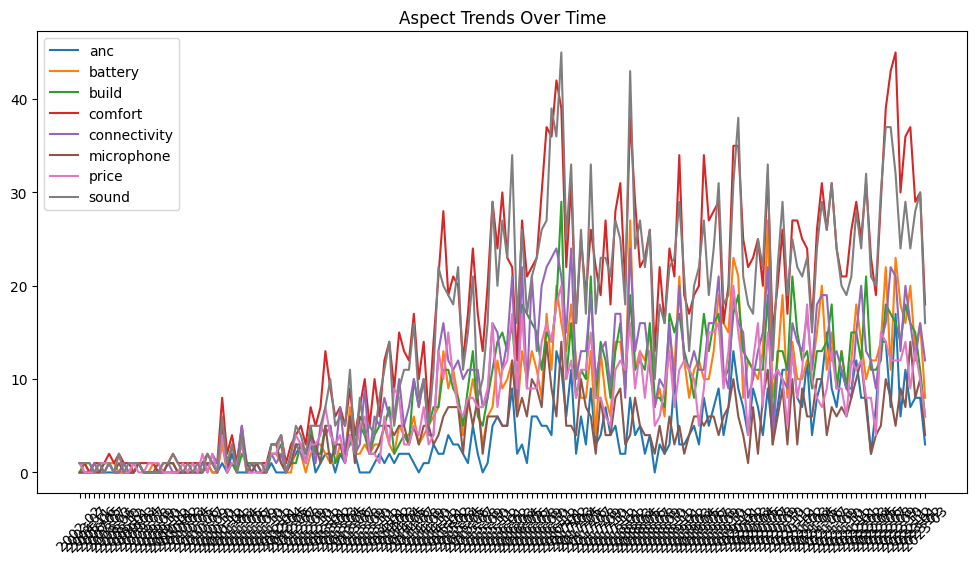

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

for col in pivot_table.columns:
    plt.plot(pivot_table.index, pivot_table[col], label=col)

plt.legend()
plt.xticks(rotation=45)
plt.title("Aspect Trends Over Time")
plt.show()

In [17]:
df_exploded = df.explode("aspects")

In [18]:
df_exploded.to_csv("/content/drive/MyDrive/CRIS/df_exploded.csv", index=False)